# 👥 Customer Analysis

## LogistiX – Enterprise Supply Chain Intelligence Platform

### Objective

This notebook analyzes customer behavior, customer segments, geographic distribution, and purchasing patterns to identify high-value customer groups and business growth opportunities.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(
    "../../Dataset/Raw/DataCoSupplyChainDataset.csv",
    encoding="latin1"
)

df.shape

(180519, 53)

In [3]:
customer_summary = pd.DataFrame({

    "Metric":[
        "Total Customers",
        "Total Orders",
        "Total Sales"
    ],

    "Value":[
        df["Customer Id"].nunique(),
        df["Order Id"].nunique(),
        f"£{df['Sales'].sum():,.2f}"
    ]

})

customer_summary

,Metric,Value
0,Total Customers,20652
1,Total Orders,65752
2,Total Sales,"£36,784,735.01"


In [4]:
segment_sales = (

    df.groupby("Customer Segment")["Sales"]

    .sum()

    .sort_values(ascending=False)

)

segment_sales

Customer Segment
Consumer       1.909579e+07
Corporate      1.116841e+07
Home Office    6.520538e+06
Name: Sales, dtype: float64

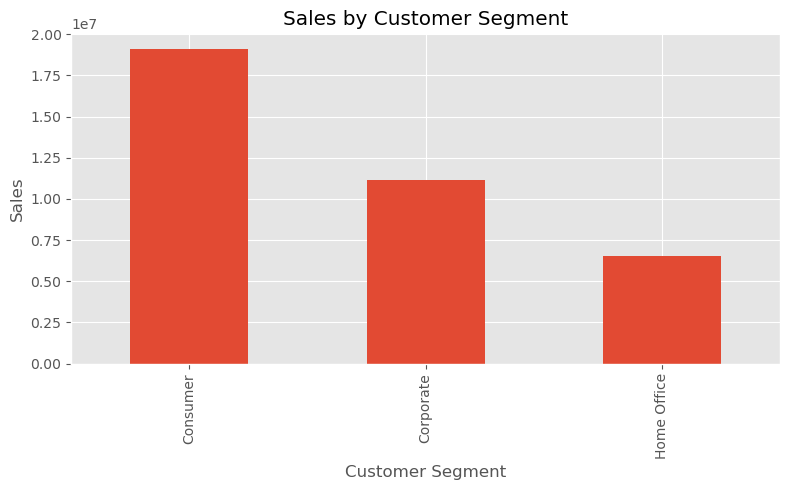

In [5]:
plt.figure(figsize=(8,5))

segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment")

plt.ylabel("Sales")

plt.xlabel("Customer Segment")

plt.tight_layout()

plt.show()

In [6]:
avg_segment = (

    df.groupby("Customer Segment")["Sales per customer"]

    .mean()

    .sort_values(ascending=False)

)

avg_segment

Customer Segment
Consumer       183.567317
Corporate      183.077806
Home Office    181.824431
Name: Sales per customer, dtype: float64

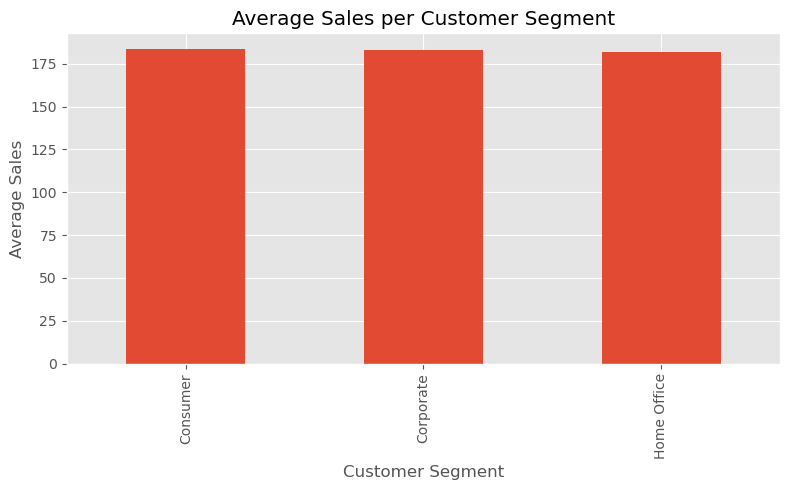

In [7]:
plt.figure(figsize=(8,5))

avg_segment.plot(kind="bar")

plt.title("Average Sales per Customer Segment")

plt.ylabel("Average Sales")

plt.tight_layout()

plt.show()

In [8]:
country_sales = (

    df.groupby("Customer Country")["Sales"]

    .sum()

    .sort_values(ascending=False)

    .head(10)

)

country_sales

Customer Country
EE. UU.        2.263449e+07
Puerto Rico    1.415024e+07
Name: Sales, dtype: float64

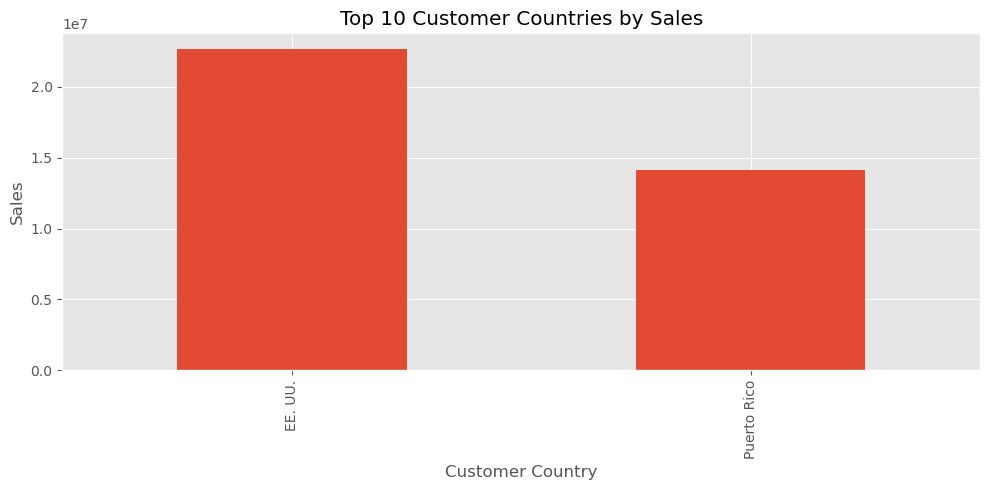

In [9]:
plt.figure(figsize=(10,5))

country_sales.plot(kind="bar")

plt.title("Top 10 Customer Countries by Sales")

plt.ylabel("Sales")

plt.tight_layout()

plt.show()

In [10]:
segment_count = (

    df["Customer Segment"]

    .value_counts()

)

segment_count

Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

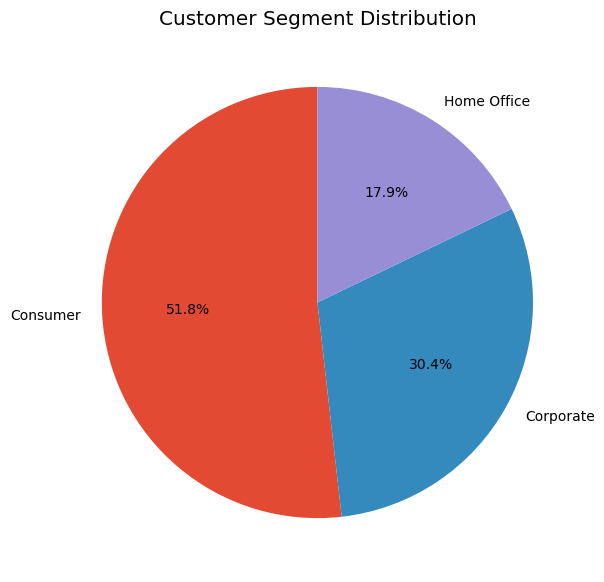

In [11]:
plt.figure(figsize=(7,7))

plt.pie(

    segment_count,

    labels=segment_count.index,

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Customer Segment Distribution")

plt.show()

# 📌 Key Customer Insights

- Consumer customers contribute the highest revenue.
- Corporate customers generate consistent purchasing volume.
- Home Office customers represent the smallest customer segment.
- Revenue is concentrated in a few countries.
- Customer segmentation reveals opportunities for targeted marketing campaigns.

# 💡 Recommendations

- Increase marketing investment for Consumer customers.
- Improve retention programs for Corporate customers.
- Expand business into emerging customer markets.
- Design personalized campaigns for Home Office customers.
- Monitor customer purchasing behavior regularly.